In [1]:
import os
import math
import numpy as np
np.random.seed(24)
import pandas as pd
from tqdm import tqdm

import shutil
import copy 
import time

from sympy import *
import operator
#from IPython.core.display import display
from IPython.display import display

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

import torch
torch.manual_seed(24)
from torch.autograd import Variable
import torch.utils.data as data_utils
import torch.nn.init as init
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms

import warnings
warnings.filterwarnings('ignore')

import cv2
from PIL import Image
from skimage.io import imread

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
sns.set_palette("bright")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
all_images_dir = './data_all_images/'
#all_images_dir = 'D:/WorkFolders/Classes/EE5885/XAI/Fall2023/Codes/Working/CNN/data_all_images'
#all_images_dir = 'C:/classes/XAI/Codes/Templates/CNN/data_all_images'
images = [i for i in os.listdir(all_images_dir) if i.endswith('png')]
len(images)

277524

In [3]:
def extract_patient_id(s):
    # split into a list
    a = s.split('_')
    # the id is the first index in the list
    patient_id = a[0]
    return patient_id

def extract_target(s):
    # split into a list
    a = s.split('_')
    # the target is part of the string in index 4
    b = a[4]
    # the ytarget i.e. 1 or 2 is the 5th index of the string --> class1
    target = b[5]
    return int(target)

def extract_x(s):
    # split into a list
    a = s.split('_')
    # the x-coodinate is part of the string in index 2
    b = a[2]
    # the x-coordinate starts from the 1st index of ths string --> x1251
    x = b[1:]
    return int(x)

def extract_y(s):
    # split into a list
    a = s.split('_')
    # the y-coodinate is part of the string in index 3
    b = a[3]
    # the y-coordinate starts from the 1st index of ths string --> y351
    y = b[1:]
    return int(y)

df_data = pd.DataFrame(images, columns=['image_id'])
# create a new column called 'patient_id'
df_data['patient_id'] = df_data['image_id'].apply(extract_patient_id)
# create a new column called 'x'
df_data['x'] = df_data['image_id'].apply(extract_x)
# create a new column called 'y'
df_data['y'] = df_data['image_id'].apply(extract_y)
# create a new column called 'target'
df_data['target'] = df_data['image_id'].apply(extract_target)

df_data.head(10)

,image_id,patient_id,x,y,target
0,16085_idx5_x2101_y701_class0.png,16085,2101,701,0
1,13460_idx5_x1401_y501_class0.png,13460,1401,501,0
2,12810_idx5_x2601_y201_class0.png,12810,2601,201,0
3,12895_idx5_x2901_y2401_class0.png,12895,2901,2401,0
4,13019_idx5_x2251_y1401_class1.png,13019,2251,1401,1
5,13022_idx5_x1251_y1201_class0.png,13022,1251,1201,0
6,14306_idx5_x1651_y251_class0.png,14306,1651,251,0
7,12897_idx5_x3701_y1501_class0.png,12897,3701,1501,0
8,9036_idx5_x1101_y2151_class0.png,9036,1101,2151,0
9,8913_idx5_x501_y601_class0.png,8913,501,601,0


In [4]:
df_data['patient_id'].nunique()

279

In [5]:
len(df_data)

277524

In [6]:
len(df_data[df_data['target'] == 1])

78786

In [7]:
len(df_data[df_data['target'] == 0])

198738

# Explore the Data

(0.0, 80.0)

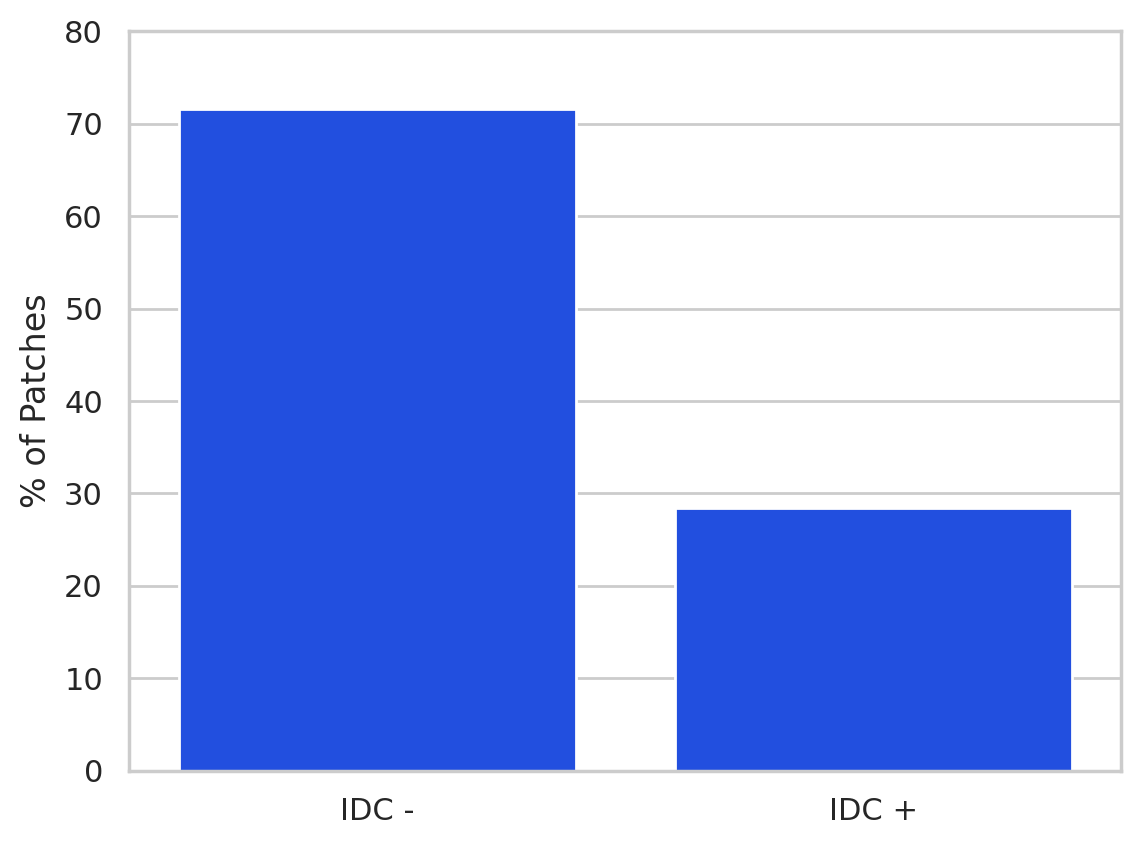

In [8]:
df_target_pc = df_data['target'].value_counts() / len(df_data) * 100
target_names = ['IDC -', 'IDC +']
target_pc = [df_target_pc[0], df_target_pc[1]]
f, ax = plt.subplots()
sns.barplot(x=target_names, y=target_pc, ax=ax)
ax.set_ylabel('% of Patches')
ax.set_ylim([0, 80])

In [9]:
df_data_pos = df_data[df_data['target'] == 1].reset_index(drop=True)
df_data_neg = df_data[df_data['target'] == 0].reset_index(drop=True)

In [10]:
num_samples = 4
df_data_pos_sample = df_data_pos.sample(n=num_samples, random_state=42).reset_index(drop=True)
df_data_neg_sample = df_data_neg.sample(n=num_samples, random_state=42).reset_index(drop=True)

IDC Positive Patches


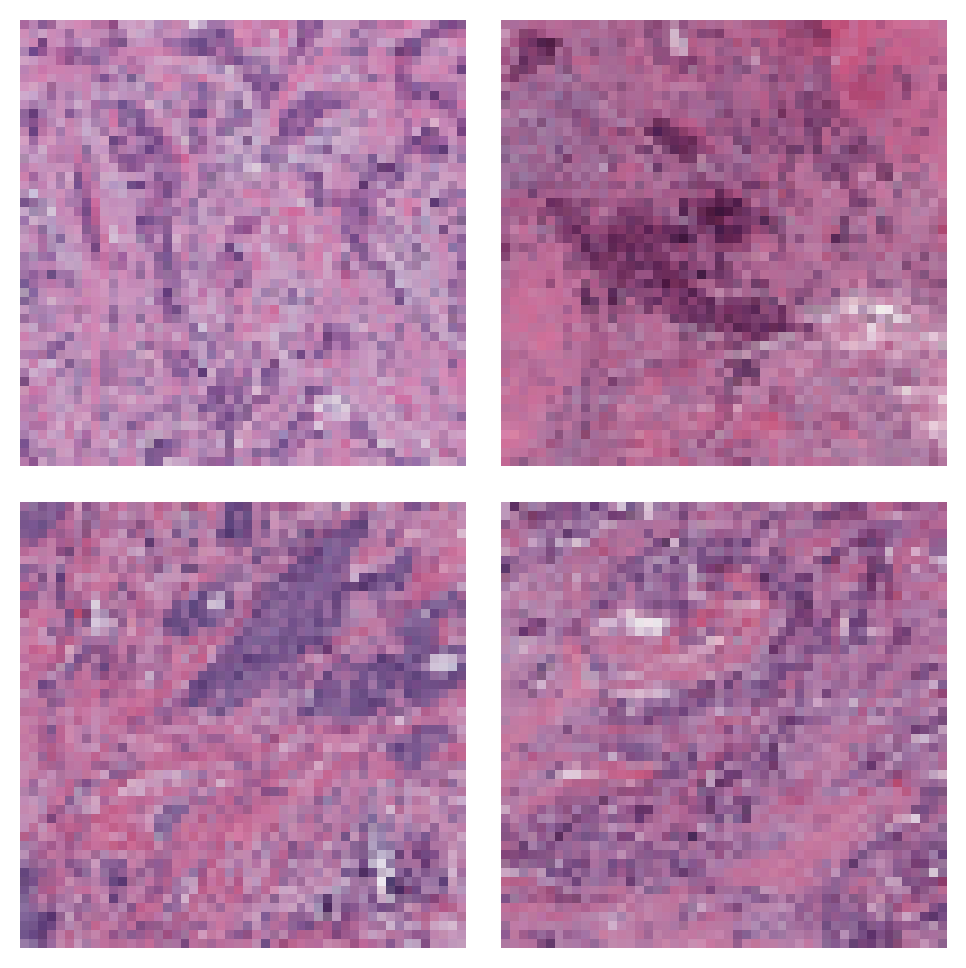

In [11]:
print('IDC Positive Patches')
f, ax = plt.subplots(2, 2, figsize=(5, 5))
axs = np.array(ax)
axs = axs.reshape(num_samples,)
for idx, row in df_data_pos_sample.iterrows():
    image_fname = row['image_id']
    im = cv2.imread(os.path.join(all_images_dir, image_fname))
    im = cv2.resize(im, (50, 50)) 
    axs[idx].imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); 
    axs[idx].axis('off')
f.tight_layout()

IDC Negative Patches


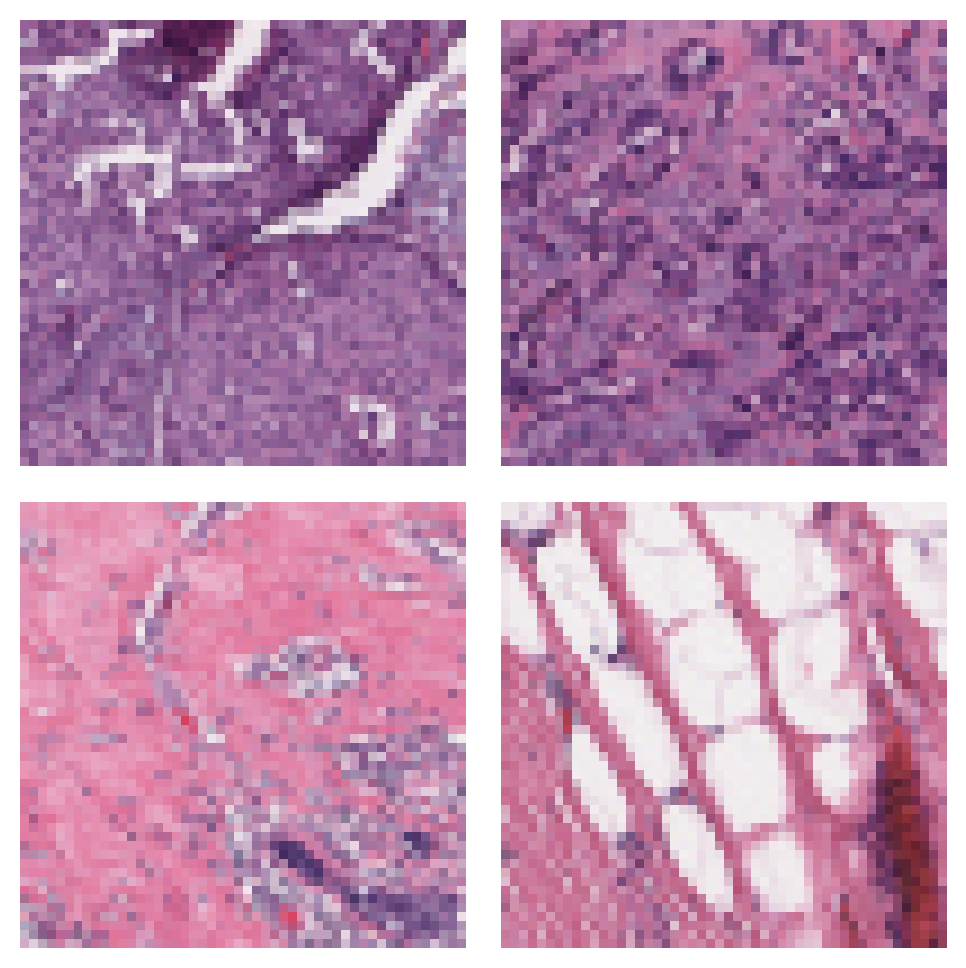

In [12]:
print('IDC Negative Patches')
f, ax = plt.subplots(2, 2, figsize=(5, 5))
axs = np.array(ax)
axs = axs.reshape(num_samples,)
for idx, row in df_data_neg_sample.iterrows():
    image_fname = row['image_id']
    im = cv2.imread(os.path.join(all_images_dir, image_fname))
    im = cv2.resize(im, (50, 50)) 
    axs[idx].imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); 
    axs[idx].axis('off')
f.tight_layout()

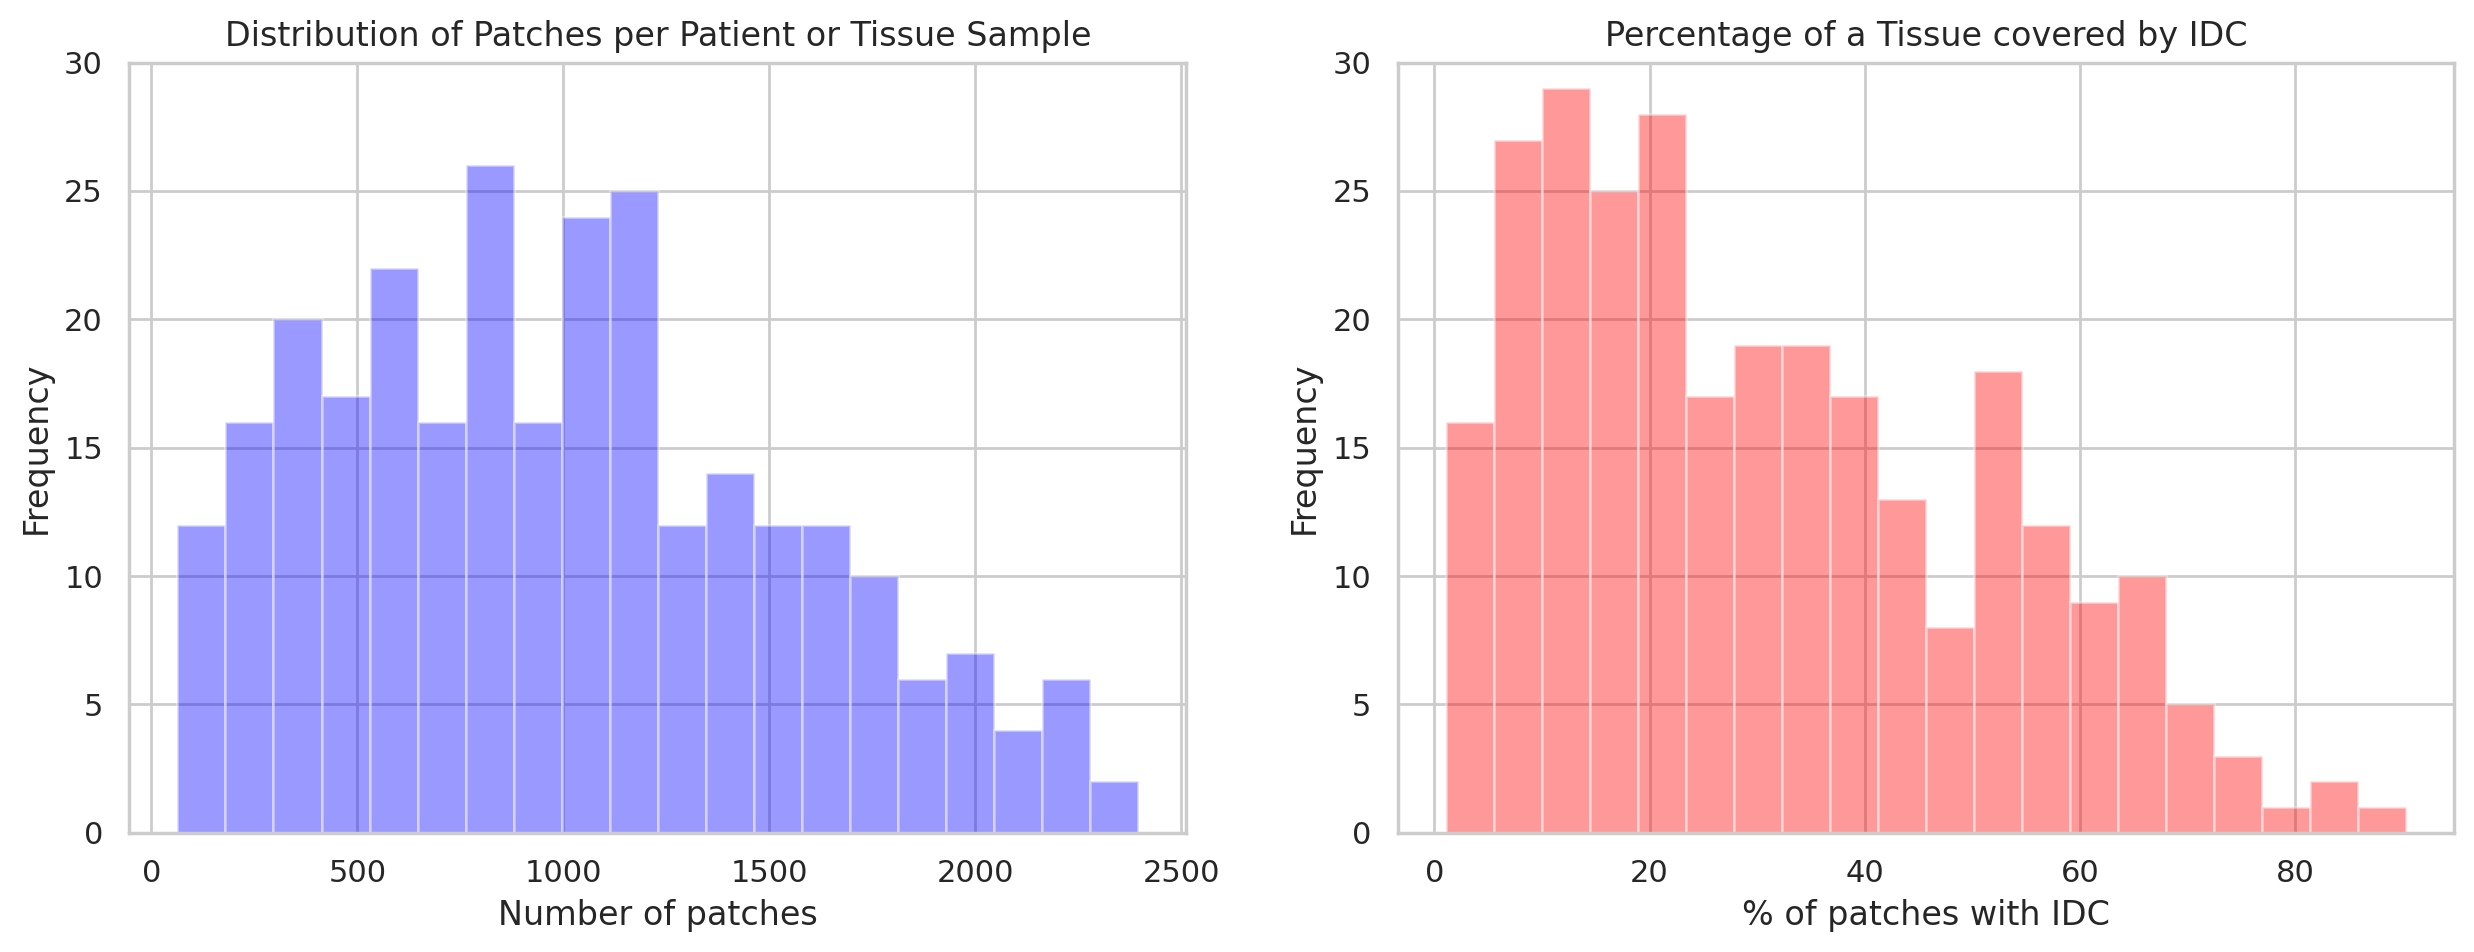

In [13]:
cancer_perc = df_data.groupby("patient_id").target.value_counts() / df_data.groupby("patient_id").target.size()
cancer_perc = cancer_perc.unstack()
f, ax = plt.subplots(1, 2,figsize=(15,5))
sns.distplot(df_data.groupby("patient_id").size(), ax=ax[0], color="Blue", kde=False, bins=20)
ax[0].set_xlabel("Number of patches")
ax[0].set_ylabel("Frequency");
ax[0].set_title("Distribution of Patches per Patient or Tissue Sample");
ax[0].set_ylim([0, 30]);
sns.distplot(cancer_perc.loc[:, 1]*100, ax=ax[1], color="Red", kde=False, bins=20)
ax[1].set_title("Percentage of a Tissue covered by IDC")
ax[1].set_ylabel("Frequency")
ax[1].set_xlabel("% of patches with IDC");
ax[1].set_ylim([0, 30]);

In [14]:
cancer_perc.loc[:, 1].max()

np.float64(0.9035087719298246)

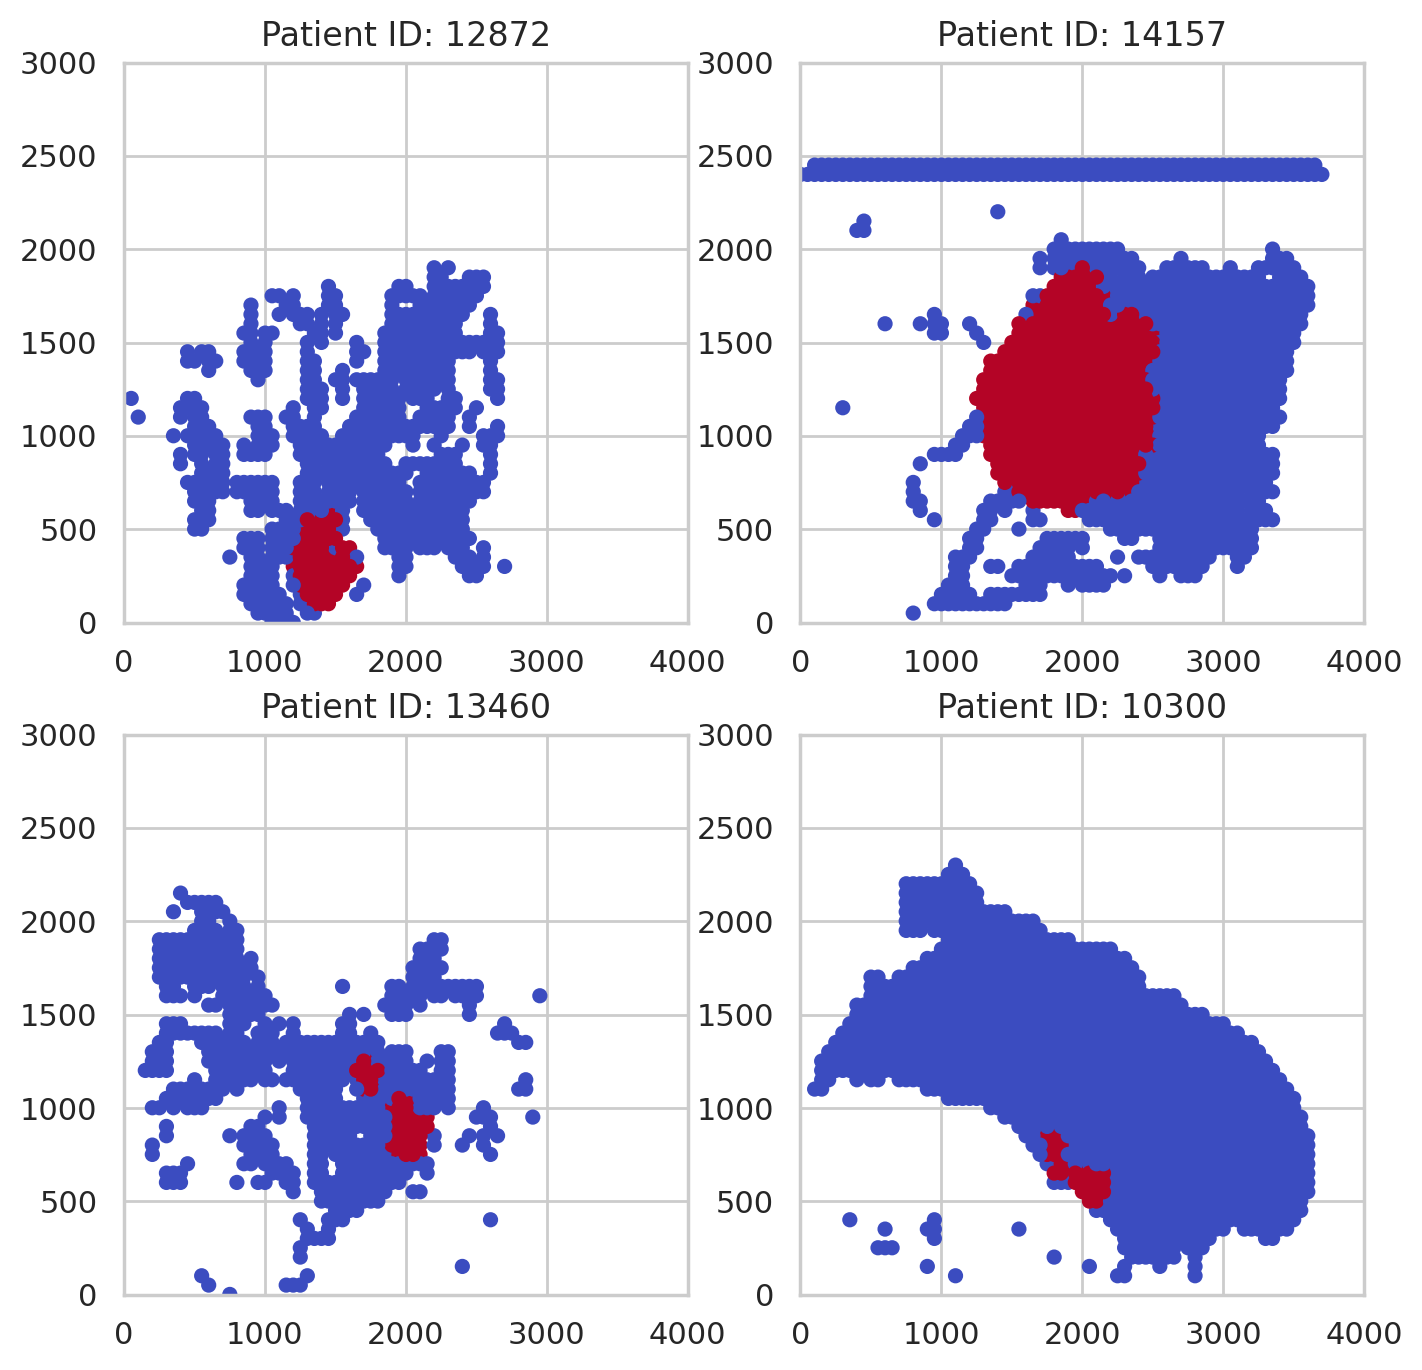

In [15]:
f, ax = plt.subplots(2, 2, figsize=(8, 8))
patient_ids = df_data.sample(frac=1, random_state=42).patient_id.unique()
for i in range(2):
    for j in range(2):
        patient_id = patient_ids[j + 3*i]
        df_patient = df_data[df_data['patient_id'] == patient_id].reset_index(drop=True)
        
        ax[i, j].scatter(df_patient.x.values, 
                         df_patient.y.values, 
                         c=df_patient.target.values, 
                         cmap="coolwarm", 
                         s=20);
        ax[i, j].set_title("Patient ID: " + patient_id)
        ax[i, j].set_xlabel("")
        ax[i, j].set_ylabel("")
        ax[i, j].set_xlim([0, 4000])
        ax[i, j].set_ylim([0, 3000])

In [16]:
df_data.to_csv('data_idc.csv', index=False)

# Prepare Data for Training

In [17]:
#Load the text data into a Pandas DataFrame
df_data = pd.read_csv('data_idc.csv')

In [18]:
#Split the using patient ID instead of splitting the data by patches
"""If the dataset is split by patches randomly, patches of one patient maybe in 
the training, validation and test datasets causing data leakage.
Therefore, split the data using the Patient ID"""
#Extract all patient unique IDs from the data
patient_ids = df_data.patient_id.unique()
train_ids, val_test_ids = train_test_split(patient_ids,
                                           test_size=0.4,
                                           random_state=24)
val_ids, test_ids = train_test_split(val_test_ids, 
                                     test_size=0.5, 
                                     random_state=24)

In [19]:
print('%% of patients in training set: %.1f%%' % (len(train_ids) / len(patient_ids) * 100))
print('%% of patients in validation set: %.1f%%' % (len(val_ids) / len(patient_ids) * 100))
print('%% of patients in test set: %.1f%%' % (len(test_ids) / len(patient_ids) * 100))

% of patients in training set: 59.9%
% of patients in validation set: 20.1%
% of patients in test set: 20.1%


In [20]:
print('Number of patients in training set: %d' % (len(train_ids)))
print('Number of patients in validation set: %d' % (len(val_ids)))
print('Number of patients in test set: %d' % (len(test_ids)))

Number of patients in training set: 167
Number of patients in validation set: 56
Number of patients in test set: 56


In [21]:
#Extract all patches for patient IDs in the training set
df_train = df_data[df_data['patient_id'].isin(train_ids)].reset_index(drop=True)
#Extract all patches for patient IDs in the validation set
df_val = df_data[df_data['patient_id'].isin(val_ids)].reset_index(drop=True)
#Extract all patches for patient IDs in the test set
df_test = df_data[df_data['patient_id'].isin(test_ids)].reset_index(drop=True)

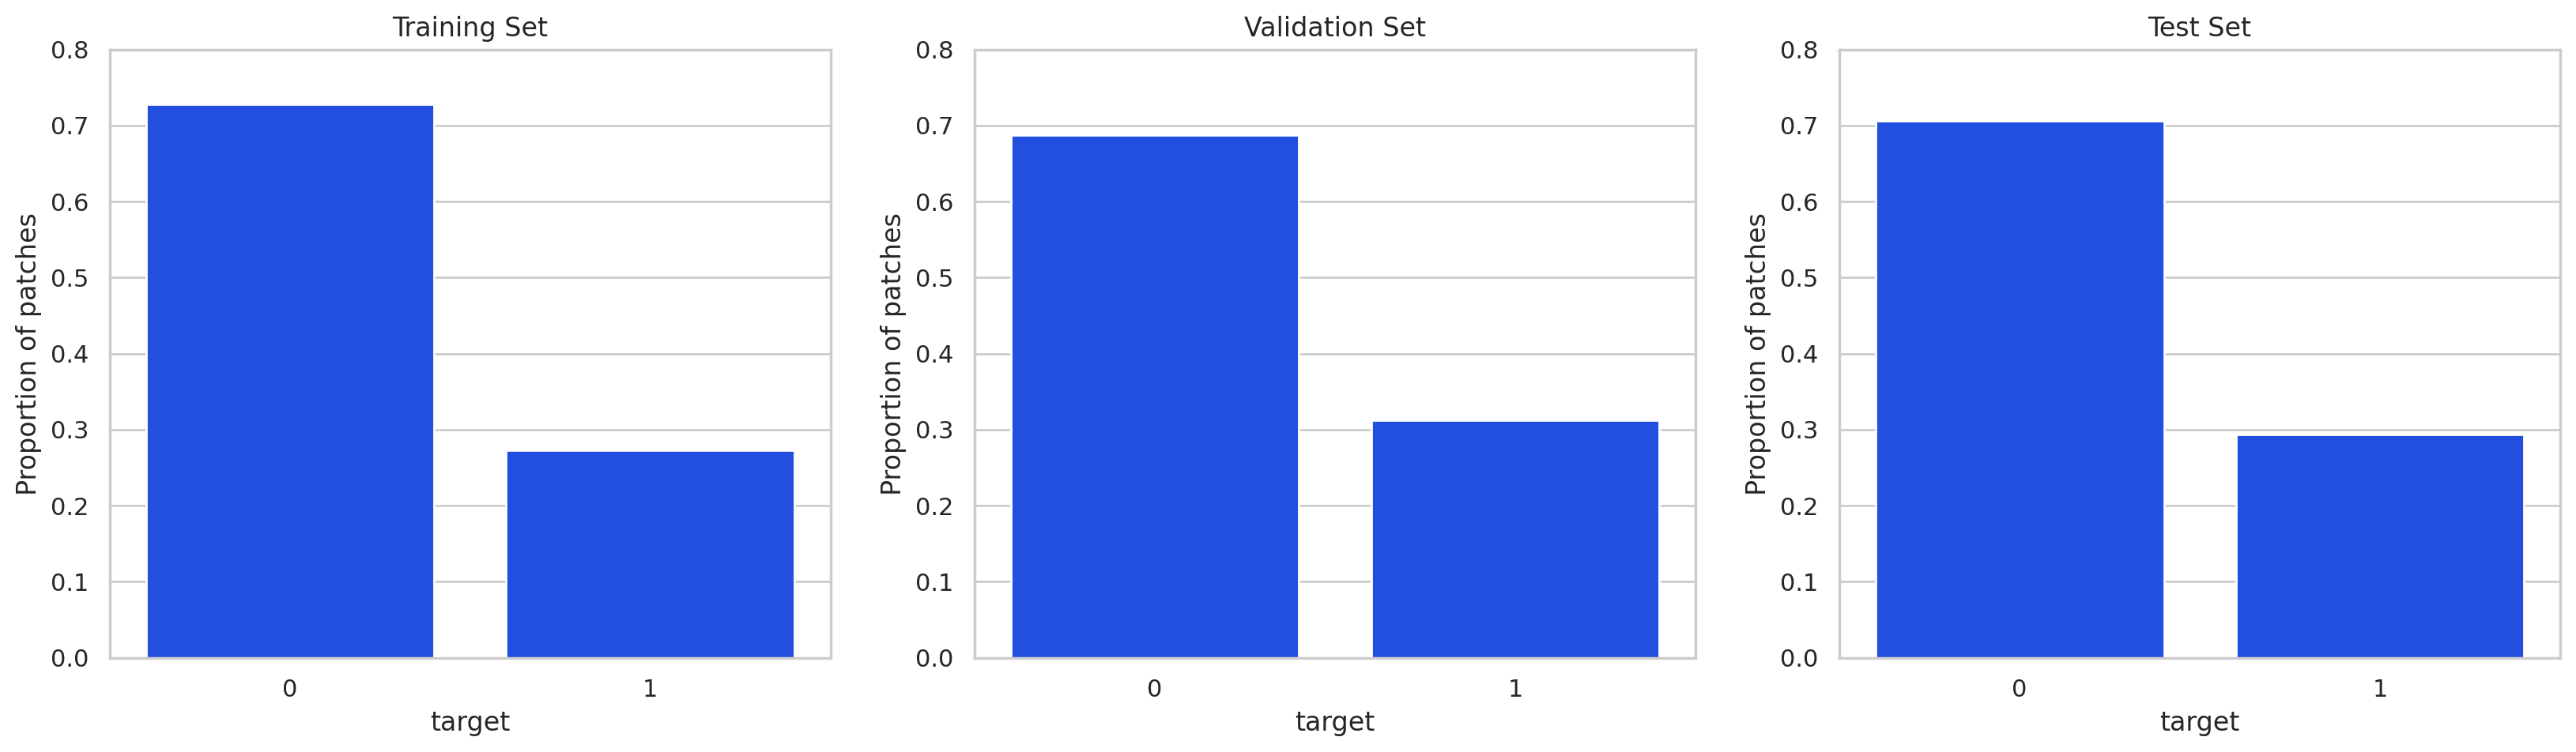

In [22]:
#Distribution of the target variable across training, validation and test dataset
f, ax = plt.subplots(1, 3, figsize=(20, 5))
df_train['target'].\
    value_counts(normalize=True).\
    rename('pc').reset_index().\
    rename(columns={'index': 'target'}).\
    pipe((sns.barplot, "data"), x='target', y='pc', ax=ax[0])
df_val['target'].\
    value_counts(normalize=True).\
    rename('pc').reset_index().\
    rename(columns={'index': 'target'}).\
    pipe((sns.barplot, "data"), x='target', y='pc', ax=ax[1])
df_test['target'].\
    value_counts(normalize=True).\
    rename('pc').reset_index().\
    rename(columns={'index': 'target'}).\
    pipe((sns.barplot, "data"), x='target', y='pc', ax=ax[2])
ax[0].set_ylabel('Proportion of patches')
ax[1].set_ylabel('Proportion of patches')
ax[2].set_ylabel('Proportion of patches')
ax[0].set_ylim([0, 0.8])
ax[1].set_ylim([0, 0.8])
ax[2].set_ylim([0, 0.8])
ax[0].set_title('Training Set')
ax[1].set_title('Validation Set')
ax[2].set_title('Test Set');

# Create Pytorch Dataset

In [23]:
#Custom class to load the images of patches and their corresponding labels
#Inherit the custom class from the PyTorch Dataset
class PatchDataset(Dataset):
    """A Constructor that intialzes the list of pathces, and
    a directory that contains the images and image transformer
    """
    def __init__(self, df_data, images_dir, transform=None):
        super().__init__()
        self.data = list(df_data.itertuples(name='Patch', index=False))
        self.images_dir = images_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)
    """Overrides the __getitem__ method to return the 
    image and label from the dataset at the position index"""
    def __getitem__(self, index):
        #Extract the image ID and label from the dataset
        image_id, label = self.data[index].image_id, self.data[index].target
        image = Image.open(os.path.join(self.images_dir, image_id))
        #Open the image and convert to RGB image
        image = image.convert('RGB')
        if self.transform is not None:
            image = self.transform(image) #Apply transformation
        return image, label

In [24]:
"""Transform the image of the patch for data augmentation"""
trans_train = transforms.Compose([
    transforms.Resize((50, 50)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])])

trans_val = transforms.Compose([transforms.Resize((50, 50)),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                                     std=[0.5, 0.5, 0.5])])

In [25]:
#Load images and labels of the patches in batches of 64
batch_size = 64
#Create the dataset object for the image patches in the training dataset
dataset_train = PatchDataset(df_data=df_train, 
                             images_dir=all_images_dir, 
                             transform=trans_train)
#Create the dataloader for the training dataset
loader_train = DataLoader(dataset=dataset_train, 
                          batch_size=batch_size, 
                          shuffle=True, 
                          num_workers=0)
#Create the dataset object for the image patches in the validation dataset
dataset_val = PatchDataset(df_data=df_val,
                           images_dir=all_images_dir,
                           transform=trans_val)
#Create the dataloader for the validation dataset
loader_val = DataLoader(dataset=dataset_val, 
                          batch_size=batch_size//2, 
                          shuffle=False, 
                          num_workers=0)
#Create the dataset object for the image patches in the test dataset
dataset_test = PatchDataset(df_data=df_test,
                            images_dir=all_images_dir,
                            transform=trans_val)
#Create the dataloader for the test dataset
loader_test = DataLoader(dataset=dataset_test, 
                         batch_size=batch_size//2, 
                         shuffle=False, 
                         num_workers=0)

In [26]:
dataloaders = {'train': loader_train,
               'val': loader_val,
               'test': loader_test}
dataset_sizes = {'train': len(df_train),
                 'val': len(df_val),
                 'test': len(df_test)}

In [27]:
# Device configuration
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [28]:
resnet18_model = torch.load('model_idc_resnet18_100epochs.pth', weights_only=False)


In [29]:
def sigmoid(x):
    return 1. / (1 + np.exp(-x))

In [30]:
def evaluate_model(model, key='test'):
    overall_proba = np.array([])
    overall_preds = np.array([])
    with torch.no_grad():
        for i, (inputs, labels) in tqdm(enumerate(dataloaders[key])):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            proba = outputs.cpu().numpy().astype(float)
            overall_preds = np.append(overall_preds, preds.cpu().numpy().astype(int))
            overall_proba = np.append(overall_proba, sigmoid(proba[:, 1]))
    return overall_proba, overall_preds

In [31]:
overall_proba, overall_preds = evaluate_model(resnet18_model)

1730it [00:25, 69.13it/s]


In [32]:
len(df_test)

55352

In [33]:
len(overall_proba)

55352

In [34]:
len(overall_preds)

55352

In [35]:
actual = df_test['target'].values
baseline = np.array([1 for _ in range(len(actual))])

In [36]:
df_test['target'].value_counts()

target
0    39095
1    16257
Name: count, dtype: int64

In [37]:
from sklearn.metrics import recall_score, precision_score, f1_score

precision = precision_score(actual, overall_preds)
p_baseline = precision_score(actual, baseline)
r_baseline = recall_score(actual, baseline)
recall = recall_score(actual, overall_preds)
f1 = f1_score(actual, overall_preds)
f1_baseline = f1_score(actual, baseline)
print('Precision: ', precision, 'Recall: ', recall, 'F1: ', f1)
print('(Baseline) Precision: ', p_baseline, 'Recall: ', r_baseline, 'F1: ', f1_baseline)

Precision:  0.8442472891142093 Recall:  0.7375284492833856 F1:  0.7872878295413507
(Baseline) Precision:  0.29370212458447753 Recall:  1.0 F1:  0.4540490720440168


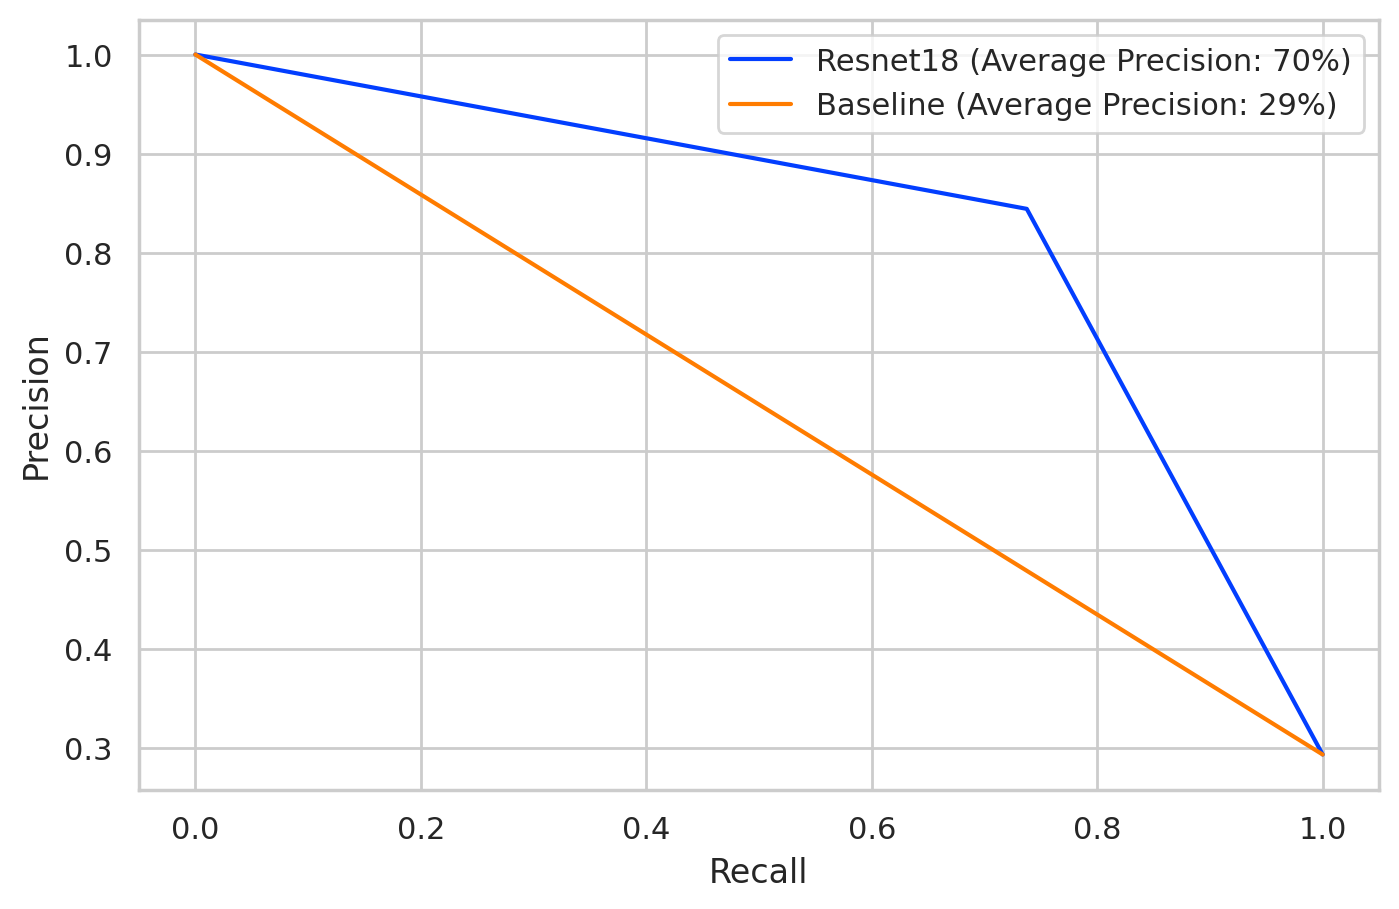

In [38]:
from sklearn.metrics import average_precision_score
pred_p, pred_r, _ = precision_recall_curve(actual, overall_preds)
baseline_p, baseline_r, _ = precision_recall_curve(actual, baseline)
pred_ap = average_precision_score(actual, overall_preds)
baseline_ap = average_precision_score(actual, baseline)
f, ax = plt.subplots(figsize=(8, 5))
ax.plot(pred_r, pred_p, label='Resnet18 (Average Precision: %d%%)' % round(pred_ap * 100))
ax.plot(baseline_r, baseline_p, label='Baseline (Average Precision: %d%%)' % round(baseline_ap * 100))
ax.legend()
ax.set_xlabel('Recall')
ax.set_ylabel('Precision');

# Complexity of Model

In [39]:
resnet18_model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [40]:
from prettytable import PrettyTable

def count_parameters(model):
    table = PrettyTable(["Modules", "Parameters"])
    total_params = 0
    for name, parameter in model.named_parameters():
        if not parameter.requires_grad: continue
        param = parameter.numel()
        table.add_row([name, param])
        total_params+=param
    print(table)
    print(f"Total Trainable Params: {total_params}")
    return total_params
    
count_parameters(resnet18_model)

+------------------------------+------------+
|           Modules            | Parameters |
+------------------------------+------------+
|         conv1.weight         |    9408    |
|          bn1.weight          |     64     |
|           bn1.bias           |     64     |
|    layer1.0.conv1.weight     |   36864    |
|     layer1.0.bn1.weight      |     64     |
|      layer1.0.bn1.bias       |     64     |
|    layer1.0.conv2.weight     |   36864    |
|     layer1.0.bn2.weight      |     64     |
|      layer1.0.bn2.bias       |     64     |
|    layer1.1.conv1.weight     |   36864    |
|     layer1.1.bn1.weight      |     64     |
|      layer1.1.bn1.bias       |     64     |
|    layer1.1.conv2.weight     |   36864    |
|     layer1.1.bn2.weight      |     64     |
|      layer1.1.bn2.bias       |     64     |
|    layer2.0.conv1.weight     |   73728    |
|     layer2.0.bn1.weight      |    128     |
|      layer2.0.bn1.bias       |    128     |
|    layer2.0.conv2.weight     |  

11572546

# Probabilistic Interpretation

In [41]:
df_test_with_preds = df_test.copy(deep=True)

In [42]:
df_test_with_preds['proba'] = overall_proba
df_test_with_preds['pred'] = overall_preds

In [43]:
df_test_with_preds.to_csv('resnet_idc_test_preds.csv', index=False)

In [44]:
df_test_with_preds = pd.read_csv('resnet_idc_test_preds.csv')
df_test_with_preds.head()

,image_id,patient_id,x,y,target,proba,pred
0,10286_idx5_x1351_y1_class0.png,10286,1351,1,0,0.093488,0.0
1,9381_idx5_x2401_y2601_class0.png,9381,2401,2601,0,0.401834,0.0
2,9037_idx5_x1551_y701_class1.png,9037,1551,701,1,0.595679,1.0
3,10273_idx5_x3051_y1501_class0.png,10273,3051,1501,0,0.301474,0.0
4,16568_idx5_x2551_y951_class0.png,16568,2551,951,0,0.191666,0.0


# LIME

In [45]:
from lime import lime_image
from functools import partial

In [46]:
#Split the transforamtion used for training into two separate transforms
"""transformation to resize the image to 50x50 pixels which
is required for the image segmentation algorithm"""
trans_pil = transforms.Compose([transforms.Resize((50,50)),])
#Transformation to convert an image to tensor and normalize
trans_pre = transforms.Compose([transforms.ToTensor(),
                               transforms.Normalize(mean=[0.5,0.5,0.5],
                                                   std = [0.5,0.5,0.5])])

In [47]:
#Helper function to read the input RGB image into memory
def get_image(images_dir,image_id):
    #Open the image
    image =Image.open(os.path.join(images_dir,image_id))
    #Convert to RGB
    image = image.convert('RGB')
    return image

In [48]:
#Helper function to perform predictions of images in perturbed dataset
def batch_predict(images,model):
    def sigmoid(x):
        return 1./(1+np.exp(-x))
    #Stack all of the transformed tensor of the input images from perturbed DS
    batch = torch.stack(tuple(trans_pre(i) for i in images),dim=0)
    #Move the perturbed images to GPU
    gpu_batch = batch.to(torch.device('cuda'))
    #Compute the model outputs
    outputs = model(gpu_batch)
    #Detach the outputs to convert to numpy array and bring it to CPU
    proba = outputs.detach().cpu().numpy().astype(float)
    return sigmoid(proba)

In [49]:
#Create a Python partial function to perform batch prediction using a model
batch_predict_with_model = partial(batch_predict,model=resnet18_model)

In [50]:
#select a negative IDC instance
non_idc_idx  = 142
#select a positive IDC instance
idc_idx  = 41291
#Using the get_image helper function load the negative IDC patch
non_idc_image = get_image(all_images_dir,
                         df_test.iloc[non_idc_idx,:]['image_id'])
#Using the get_image helper function load the positive IDC patch
idc_image = get_image(all_images_dir,
                         df_test.iloc[idc_idx,:]['image_id'])


In [51]:
#using the partial function do a batch prediction
batch_predict_with_model([trans_pil(non_idc_image),trans_pil(idc_image)])

array([[0.33193709, 0.43983421],
       [0.10021213, 0.69853272]])

In [52]:
#Resize the negative IDC image
np.array(trans_pil(non_idc_image)).shape

(50, 50, 3)

In [53]:
#Create a LimeExplainer Object
explainer = lime_image.LimeImageExplainer()

In [54]:
#Call the explain_instance method to generate explanations for a prediction
"""Arguments:
first argument: Tranform the selected image to a 50x50 pixel image,
second argument: partial function to predict the perturbed dataset
third argument: Number of perturbed images to be created
return value: LIME explanation variable which will contain the RGB segment
image and a 2D mask explaining the segmentation boundary and +ve or _ve
contribution"""
non_idc_exp = explainer.explain_instance(np.array(trans_pil(non_idc_image)),
                                        batch_predict_with_model,
                                        num_samples = 1000)

100%|██████████| 1000/1000 [00:00<00:00, 1264.30it/s]


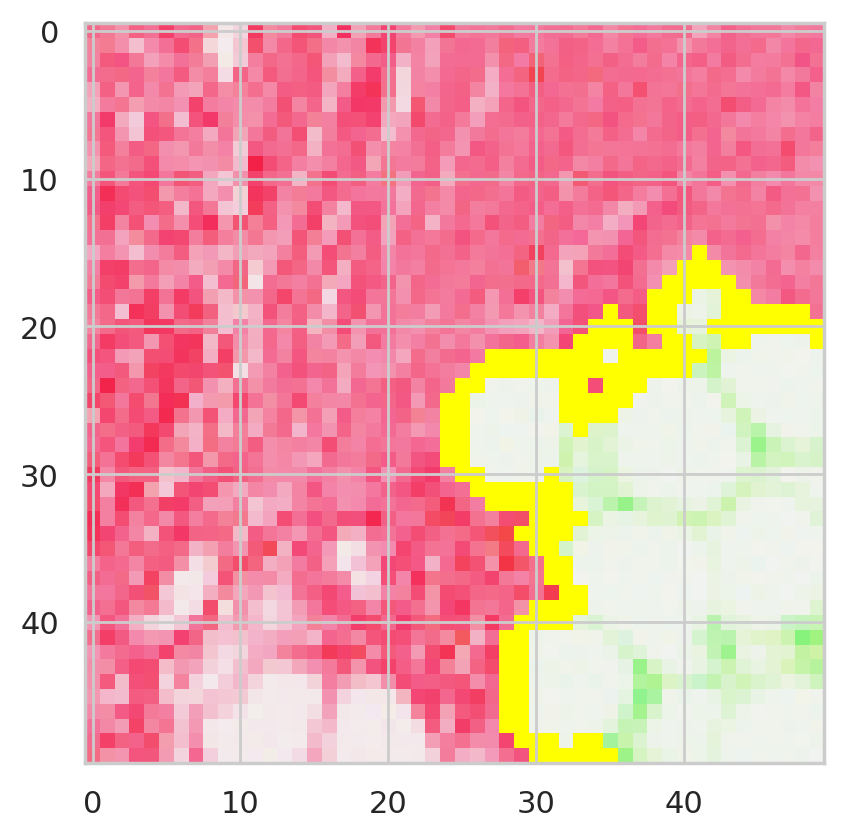

In [55]:
"""Import the mark_boundaries function from the skimage library
to plot the segmented image"""
"""Use the get_image_and_mask function to obtain the segmented image and 
mask"""
"""Arguments:
1. the label to be explained. It should be zero because IDC positive 1
2. Boolean variable
    True: Will consider only the superpixels that positively contribute to
    the label prediction
    False: Both contributions are considered, but a single segment can't
    contribute +ve and _ve
3. Number of superpixels to include in the explanation
4. Boolean: True: make the non-explanation part of the segment image gray"""
from skimage.segmentation import mark_boundaries
ni_tmp,ni_mask = non_idc_exp.get_image_and_mask(
    non_idc_exp.top_labels[0],
    positive_only = False,
    num_features = 20,
    hide_rest = True
)
ni_img_boundary =mark_boundaries(ni_tmp/255.0,ni_mask)
plt.imshow(ni_img_boundary)

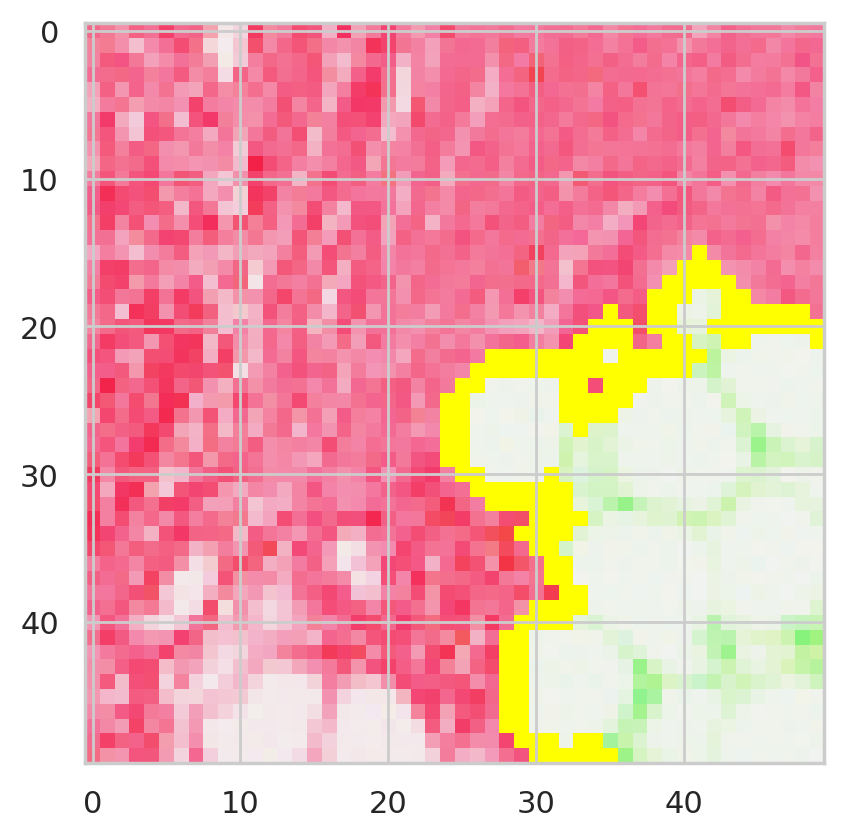

In [56]:
#Using the get_image_and_mask function obtain the segmented image and the 2D mask
"""Arguments:
First argument: label to explain. It is zero because IDC Positive is one
second argument: if True, only take superpixels that positively contribute
to the prediction of the label. If false, both negative and postive contributions
will be taken, but both can't be true at the same time
third argument: Number of superpixels to include in the explanation
fourth argument: if True, make the non-explanantion part of the return image gray"""
ni_tmp, ni_mask = non_idc_exp.get_image_and_mask(non_idc_exp.top_labels[0], 
                                                 positive_only=False, 
                                                 num_features=20, 
                                                 hide_rest=True)
#Plot the masked image using the mark_boundaries function
"""Return image with boundaries between labeled regions highlighted
and. The image in which the boundaries between labels are 
superimposed on the original image"""
ni_img_boundary = mark_boundaries(ni_tmp/255.0, ni_mask)
plt.imshow(ni_img_boundary)

In [57]:
#Obtain explanantion for the positive idc image
np.array(trans_pil(idc_image)).shape
idc_exp = explainer.explain_instance(np.array(trans_pil(idc_image)), 
                                     batch_predict_with_model, 
                                     num_samples=1000)

100%|██████████| 1000/1000 [00:00<00:00, 1629.18it/s]


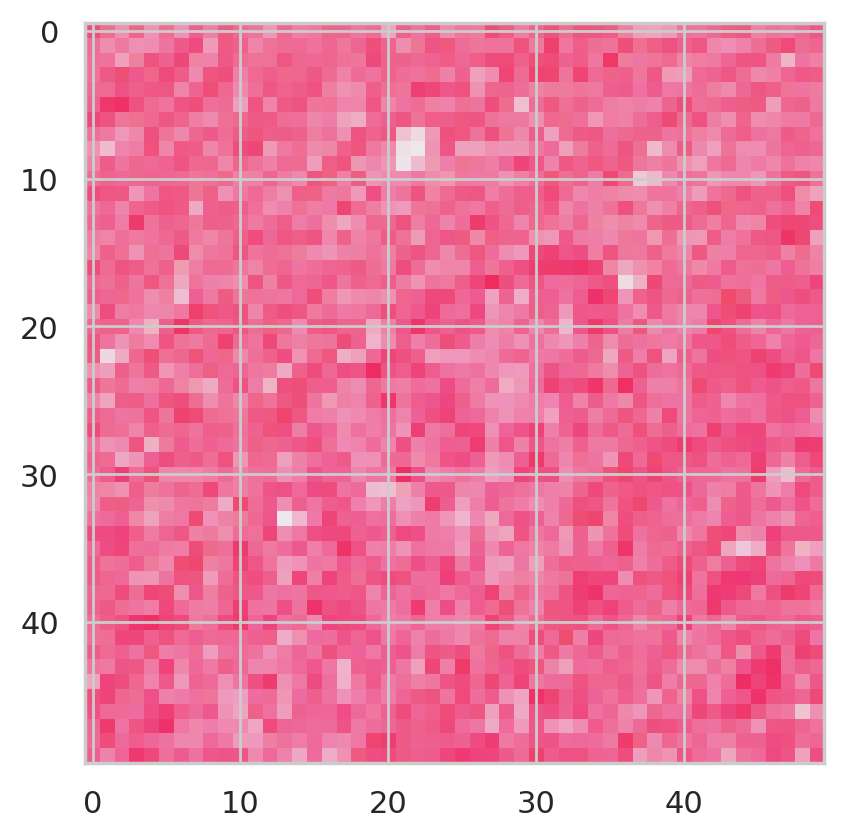

In [58]:
i_tmp, i_mask = idc_exp.get_image_and_mask(idc_exp.top_labels[1], 
                                           positive_only=False, 
                                           num_features=20, 
                                           hide_rest=True)
idc_img_boundary = mark_boundaries(i_tmp/255.0, i_mask)
plt.imshow(idc_img_boundary)

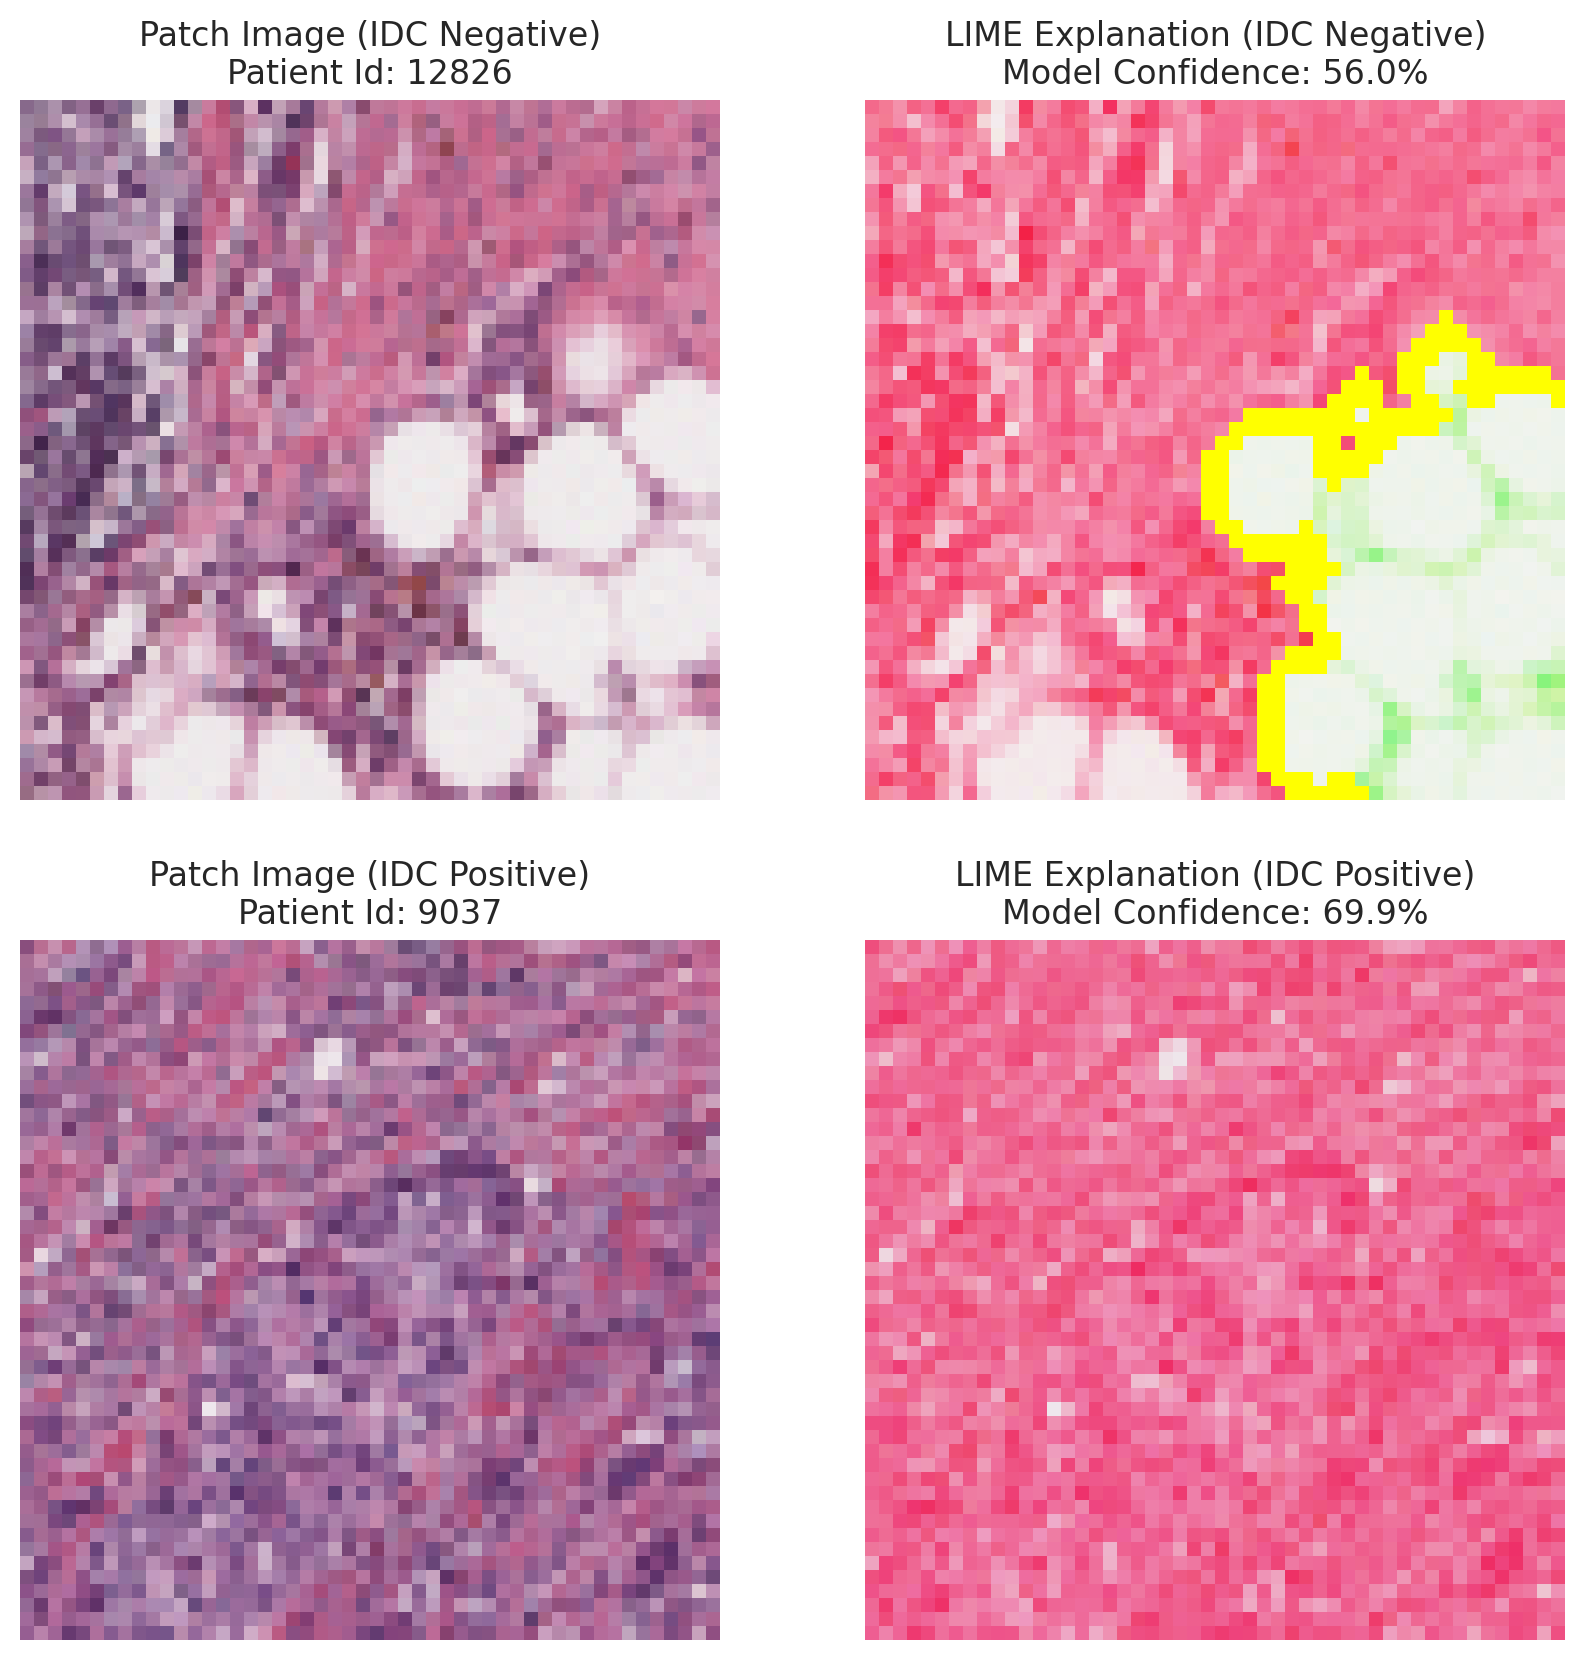

In [59]:
#Obtain the model confidence of the IDC-negative patch
non_idc_conf = 100 - df_test_with_preds.iloc[non_idc_idx]['proba'] * 100
#Obtain the model confidence of the IDC-positive patch
idc_conf = df_test_with_preds.iloc[idc_idx]['proba'] * 100
#Obtain the IDC-negative image
non_idc_image = df_test.iloc[non_idc_idx]['image_id']
#Obtain the IDC-positive image
idc_image = df_test.iloc[idc_idx]['image_id']
#obtain the patient id of the IDC-negative image
non_idc_patient = df_test.iloc[non_idc_idx]['patient_id']
#obtain the patient id of the IDC-positive image
idc_patient = df_test.iloc[idc_idx]['patient_id']
#Plot the original image and LIME explanation
f, ax = plt.subplots(2, 2, figsize=(10, 10))
ax[0][0].imshow(Image.fromarray(imread(os.path.join(all_images_dir, non_idc_image))))
ax[0][0].axis('off')
ax[0][0].set_title('Patch Image (IDC Negative)\nPatient Id: %d' % non_idc_patient)
ax[0][1].imshow(ni_img_boundary)
ax[0][1].axis('off')
ax[0][1].set_title('LIME Explanation (IDC Negative)\nModel Confidence: %.1f%%' % non_idc_conf)
ax[1][0].imshow(Image.fromarray(imread(os.path.join(all_images_dir, idc_image))))
ax[1][0].axis('off')
ax[1][0].set_title('Patch Image (IDC Positive)\nPatient Id: %d' % idc_patient)
ax[1][1].imshow(idc_img_boundary)
ax[1][1].axis('off')
ax[1][1].set_title('LIME Explanation (IDC Positive)\nModel Confidence: %.1f%%' % idc_conf);